In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

import os
import random
import keras

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report
import tensorflow as tf

In [2]:
c = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Cyst'
n = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Normal'
s = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone'
t = '/kaggle/input/ct-kidney-dataset-normal-cyst-tumor-and-stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Tumor'

In [3]:
random.seed(42)
filenames = os.listdir(c) + random.sample(os.listdir(n), 2500) + os.listdir(s) + os.listdir(t)

In [4]:
categories = []
for filename in filenames:
    category = filename.split('-')[0]
    if category == 'Cyst':
        categories.append(str(3))
    elif category == 'Normal':
        categories.append(str(2))
    elif category == 'Stone':
        categories.append(str(1))
    else:
        categories.append(str(0))

In [5]:
for i in range(len(filenames)):
    if 'Cyst' in filenames[i]:
        filenames[i] = os.path.join(c, filenames[i])
    elif 'Normal' in filenames[i]:
        filenames[i] = os.path.join(n, filenames[i])
    elif 'Stone' in filenames[i]:
        filenames[i] = os.path.join(s, filenames[i])
    else:
        filenames[i] = os.path.join(t, filenames[i])


df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

In [6]:
df.head()

,filename,category
0,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,3
1,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,3
2,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,3
3,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,3
4,/kaggle/input/ct-kidney-dataset-normal-cyst-tu...,3


In [10]:
df.shape

(9869, 2)

In [7]:
train_data, test_valid_data = train_test_split(df, test_size=0.2, random_state = 42, shuffle=True, stratify=df['category'])
train_data = train_data.reset_index(drop=True)
test_valid_data = test_valid_data.reset_index(drop=True)

In [8]:
test_data, valid_data = train_test_split(test_valid_data, test_size=0.5, random_state = 42,
                                         shuffle=True, stratify=test_valid_data['category'])
test_data = test_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)

In [13]:
train_data.shape

(7895, 2)

In [14]:
test_data.shape

(987, 2)

In [9]:
train_data_gen = ImageDataGenerator(
    rotation_range=15,
    rescale=1./255,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

In [10]:
train_generator = train_data_gen.flow_from_dataframe(
    train_data,
    x_col='filename',
    y_col='category',
    target_size=(128,128),
    class_mode='categorical',
    batch_size=32
)

Found 7895 validated image filenames belonging to 4 classes.


In [11]:
valid_data_gen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_data_gen.flow_from_dataframe(
    valid_data,
    x_col='filename',
    y_col='category',
    target_size=(128,128),
    class_mode='categorical',
    batch_size=32
)

Found 987 validated image filenames belonging to 4 classes.


In [12]:
import tensorflow as tf
base_model3 = tf.keras.applications.ResNet50V2(weights='imagenet', input_shape = (128,128,3),
                                                     include_top=False)
for layer in base_model3.layers:
    layer.trainable = False

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [13]:
model3 = tf.keras.Sequential([
    base_model3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(4, activation='softmax')
])

callbacks = [

    tf.keras.callbacks.EarlyStopping(patience=3, monitor='val_loss', verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]



from tensorflow.keras.optimizers import Adam
opt = Adam(learning_rate=0.001)


model3.compile(optimizer = opt,
              loss = 'categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
history3 = model3.fit(train_generator,
                    validation_data=valid_generator, epochs=10,
                    callbacks=[callbacks])

Epoch 1/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.6042 - loss: 1.0079 - val_accuracy: 0.7953 - val_loss: 0.5363 - learning_rate: 0.0010
Epoch 2/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.7714 - loss: 0.5960 - val_accuracy: 0.8237 - val_loss: 0.4871 - learning_rate: 0.0010
Epoch 3/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 230s 923ms/step - accuracy: 0.8040 - loss: 0.5149 - val_accuracy: 0.7893 - val_loss: 0.5401 - learning_rate: 0.0010
Epoch 4/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 239s 962ms/step - accuracy: 0.8186 - loss: 0.4902 - val_accuracy: 0.8521 - val_loss: 0.3973 - learning_rate: 0.0010
Epoch 5/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 226s 908ms/step - accuracy: 0.8350 - loss: 0.4472 - val_accuracy: 0.8571 - val_loss: 0.4008 - learning_rate: 0.0010
Epoch 6/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 224s 899ms/step - accuracy: 0.8418 - loss: 0.4397 - val_accuracy: 0.8825 - val_loss: 0.3306 - learning_rate: 0.0010
Epoch 7/10
247/247 ━━━━━━━━━━━━━━━━━━━━ 240s 963ms/step - accuracy: 0.

In [15]:
model3.save("model3.h5")

In [ ]:
test_set = valid_data_gen.flow_from_dataframe(
    test_data,
    x_col='filename',
    y_col='category',
    target_size=(224,224),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

In [ ]:
ytest=model3.evaluate(test_set)

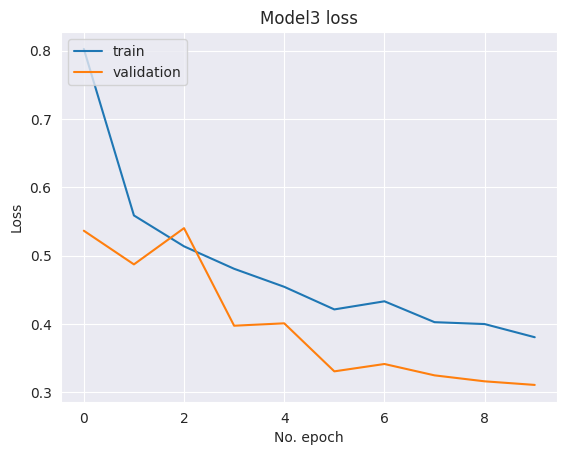

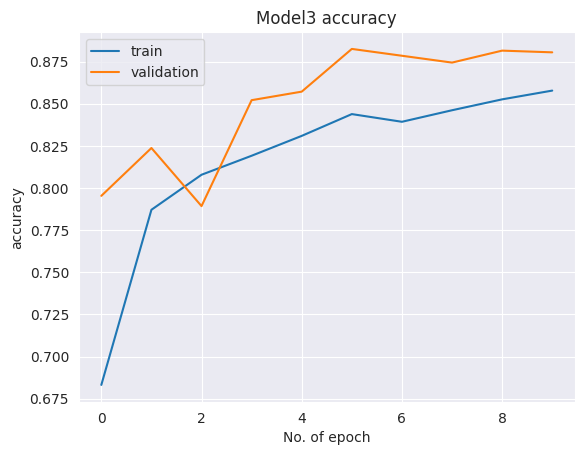

In [19]:
plt.plot(history3.history['loss'], label='Loss (training data)')
plt.plot(history3.history['val_loss'], label='Loss (validation data)')
plt.title('Model3 loss')
plt.ylabel('Loss')
plt.xlabel('No. epoch')
plt.legend(['train', 'validation'], loc="upper left")
plt.savefig('graph11.png', dpi=300, bbox_inches='tight')
plt.show()
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.title('Model3 accuracy')
plt.ylabel('accuracy')
plt.xlabel('No. of epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.savefig('graph12.png', dpi=300, bbox_inches='tight')
plt.show()
